In [1]:
!pip install imbalanced-learn

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('mail_data (1).csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df = df.where((pd.notnull(df)), '')

# Convert labels
df.loc[df['Category'] == 'spam', 'Category'] = 0
df.loc[df['Category'] == 'ham', 'Category'] = 1

df['Category'] = df['Category'].astype('int')

In [9]:
X = df['Message']
y = df['Category']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    lowercase=True,
    max_df=0.9,
    min_df=5,
    ngram_range=(1,2)
)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [12]:
smote = SMOTE()
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [13]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC()
}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)

In [15]:
for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Naive Bayes
Accuracy: 0.9434977578475336
              precision    recall  f1-score   support

           0       0.72      0.95      0.82       149
           1       0.99      0.94      0.97       966

    accuracy                           0.94      1115
   macro avg       0.85      0.95      0.89      1115
weighted avg       0.96      0.94      0.95      1115


Logistic Regression
Accuracy: 0.9748878923766816
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       149
           1       0.99      0.98      0.99       966

    accuracy                           0.97      1115
   macro avg       0.94      0.96      0.95      1115
weighted avg       0.98      0.97      0.98      1115


SVM
Accuracy: 0.9390134529147982
              precision    recall  f1-score   support

           0       0.70      0.95      0.81       149
           1       0.99      0.94      0.96       966

    accuracy                           0.94      1115
  

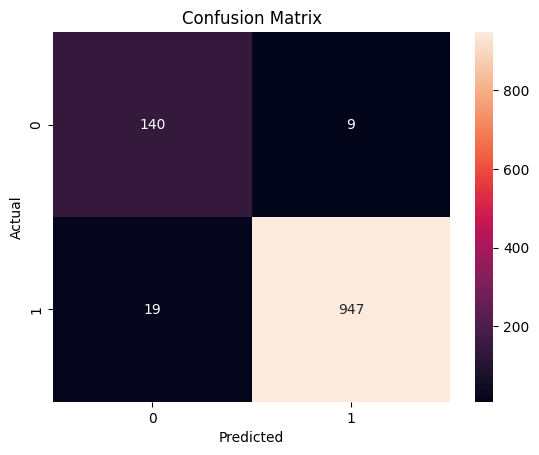

In [20]:
best_model = models["Logistic Regression"]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
def predict_mail(text):
    vector = vectorizer.transform([text])
    result = best_model.predict(vector)

    return "Spam" if result[0] == 0 else "Ham"

In [19]:
sample = "Congratulations! You have won a free ticket. Click now!"
print(predict_mail(sample))

Spam
